# XGBoost — Fraud Detection (PaySim)

XGBoost for binary transaction fraud classification, comparing raw vs engineered features.

## Pipeline
1. isFlaggedFraud leakage investigation
2. **Part A — with feature engineering** (4 derived balance-delta features)
   - Variants: no imbalance handling / scale_pos_weight / SMOTE (strategy=0.1)
3. **Part B — without feature engineering** (raw PaySim features only, ablation)
   - Same three variants for a clean comparison against Part A
4. Combined comparison table: FE vs no-FE across all variants

## Setup

In [14]:
import random
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 42
set_seed(SEED)
print(f"Random seed: {SEED}")

Random seed: 42


In [15]:
project_root = Path.cwd().parent
src_dir      = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

processed_dir = project_root / "data" / "processed"
results_root  = project_root / "results"

print("Project root  :", project_root)
print("Processed dir :", processed_dir)
print("Results root  :", results_root)

Project root  : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Processed dir : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed
Results root  : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results


In [16]:
import tabular_xgboost_utils
importlib.reload(tabular_xgboost_utils)

from tabular_xgboost_utils import (
    prepare_dataframes,
    build_preprocessor,
    compute_scale_pos_weight,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
    investigate_flagged_fraud,
)

print("Loaded from:", tabular_xgboost_utils.__file__)

Loaded from: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\tabular_xgboost_utils.py


## Data loading

In [17]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val   = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test  = pd.read_csv(processed_dir / "paysim_test.csv")

print("Train :", paysim_train.shape)
print("Val   :", paysim_val.shape)
print("Test  :", paysim_test.shape)

print("\nTrain class distribution:")
print(paysim_train["isFraud"].value_counts())

Train : (4453834, 12)
Val   : (636262, 12)
Test  : (1272524, 12)

Train class distribution:
isFraud
0    4448085
1       5749
Name: count, dtype: int64


## isFlaggedFraud investigation

PaySim contains a rule-based flag (`isFlaggedFraud`) that fires when a TRANSFER
exceeds 200,000 units. Before training we check whether this flag captures most
fraud (a potential shortcut) or only a small fraction of it (a legitimate weak signal).

In [18]:
flagged_report = investigate_flagged_fraud(paysim_train, split_name="train")

fraud_by_type = (
    paysim_train.groupby("type")["isFraud"]
    .agg(total="count", fraud_count="sum")
    .assign(fraud_rate=lambda x: (x["fraud_count"] / x["total"] * 100).round(3))
    .sort_values("fraud_count", ascending=False)
)
print("\nFraud distribution by transaction type (train):")
print(fraud_by_type.to_string())


=== isFlaggedFraud analysis — TRAIN ===
Total fraud cases       : 5,749
Flagged transactions    : 14
Flagged AND fraud       : 14
Coverage  (flag recall) : 0.24%
Precision (flag)        : 100.00%
Verdict                 : LOW COVERAGE — not a meaningful shortcut. Safe to keep.

Type breakdown of flagged transactions:
  4             flagged=14  fraud=14  (100.0% fraud)

Fraud distribution by transaction type (train):
        total  fraud_count  fraud_rate
type                                  
1     1566250         2883       0.184
4      373140         2866       0.768
0      979357            0       0.000
2       29102            0       0.000
3     1505985            0       0.000


## Experiment helper

In [19]:
def run_experiment(
    label: str,
    results_dir: Path,
    imbalance_method: str,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    numeric_features,
    categorical_features,
    scale_pos_weight_val: float,
    smote_strategy: float = 0.1,
) -> dict:
    """Build, train, evaluate, tune threshold, and save one XGBoost variant."""
    results_dir.mkdir(parents=True, exist_ok=True)

    preprocessor = build_preprocessor(numeric_features, categorical_features)
    model = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method=imbalance_method,
        scale_pos_weight=scale_pos_weight_val,
        smote_sampling_strategy=smote_strategy,
    )

    print(f"\n{'='*60}")
    print(f"Training: {label}")
    print(f"{'='*60}")
    model = fit_model(model, X_train, y_train, eval_set=(X_val, y_val))

    val_metrics,  val_cm  = evaluate_model(model, X_val,  y_val,  f"{label} — val")
    test_metrics, test_cm = evaluate_model(model, X_test, y_test, f"{label} — test")

    threshold_results = search_thresholds(model, X_val, y_val)
    cost_df           = compute_cost_table(threshold_results, y_val)
    best_threshold    = float(cost_df.iloc[0]["threshold"])
    print(f"\nBest threshold (min expected cost on val): {best_threshold:.2f}")

    tuned_metrics, tuned_cm = evaluate_with_threshold(
        model, X_test, y_test, best_threshold
    )
    cost_summary = compute_expected_cost_from_cm(tuned_cm)
    print(f"Expected cost on test set: {cost_summary['expected_cost']:,}")

    save_experiment_outputs(
        results_dir=results_dir,
        model=model,
        val_metrics=val_metrics,
        test_metrics=test_metrics,
        val_cm=val_cm,
        test_cm=test_cm,
        threshold_results=threshold_results,
        cost_df=cost_df,
        tuned_metrics=tuned_metrics,
        tuned_cm=tuned_cm,
        prefix=label.replace(" ", "_").replace("—", "").strip("_"),
    )
    print(f"Saved to: {results_dir}")

    return {
        "label":             label,
        "val_metrics":       val_metrics,
        "test_metrics":      test_metrics,
        "best_threshold":    best_threshold,
        "tuned_metrics":     tuned_metrics,
        "cost_summary":      cost_summary,
        "tuned_cm":          tuned_cm,
        "threshold_results": threshold_results,
        "cost_df":           cost_df,
    }

---
## Part A — With feature engineering

Four balance-delta features are added to the raw PaySim columns:
`balance_delta_orig`, `balance_delta_dest`, `amount_to_balance_ratio`,
`orig_balance_zeroed`. Each is computed independently on every split to
prevent any form of data leakage.

In [20]:
data_fe = prepare_dataframes(
    paysim_train, paysim_val, paysim_test,
    use_feature_engineering=True,
)

X_train_fe = data_fe["X_train"]
y_train_fe = data_fe["y_train"]
X_val_fe   = data_fe["X_val"]
y_val_fe   = data_fe["y_val"]
X_test_fe  = data_fe["X_test"]
y_test_fe  = data_fe["y_test"]

numeric_features_fe     = data_fe["numeric_features"]
categorical_features_fe = data_fe["categorical_features"]
spw_fe                  = compute_scale_pos_weight(y_train_fe)

print("Features:", data_fe["feature_cols"])
print("X_train shape:", X_train_fe.shape)
print("scale_pos_weight:", spw_fe)

# Sanity check — engineered columns must be present
for col in ["balance_delta_orig", "balance_delta_dest",
            "amount_to_balance_ratio", "orig_balance_zeroed"]:
    assert col in X_train_fe.columns, f"Missing engineered feature: {col}"
print("\nFeature engineering confirmed.")

Features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']
X_train shape: (4453834, 12)
scale_pos_weight: 773.7145590537485

Feature engineering confirmed.


### A.1 — No imbalance handling

In [21]:
result_fe_none = run_experiment(
    label              = "fe_none",
    results_dir        = results_root / "xgb_fe_none",
    imbalance_method   = "none",
    X_train=X_train_fe, y_train=y_train_fe,
    X_val=X_val_fe,     y_val=y_val_fe,
    X_test=X_test_fe,   y_test=y_test_fe,
    numeric_features   = numeric_features_fe,
    categorical_features = categorical_features_fe,
    scale_pos_weight_val = spw_fe,
)


Training: fe_none
  Early stopping: used 296 / 300 trees.

=== FE_NONE — VAL ===
  accuracy: 0.999852
  precision: 0.952677
  recall: 0.931790
  f1: 0.942118
  roc_auc: 0.999987
  pr_auc: 0.990648

Confusion matrix:
 [[635403     38]
 [    56    765]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999    635441
           1     0.9527    0.9318    0.9421       821

    accuracy                         0.9999    636262
   macro avg     0.9763    0.9659    0.9710    636262
weighted avg     0.9999    0.9999    0.9999    636262


=== FE_NONE — TEST ===
  accuracy: 0.999870
  precision: 0.958437
  recall: 0.940353
  f1: 0.949309
  roc_auc: 0.999565
  pr_auc: 0.991117

Confusion matrix:
 [[1270814      67]
 [     98    1545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   1270881
           1     0.9584    0.9404    0.9493      1643

    accur

### A.2 — scale_pos_weight

In [22]:
result_fe_weighted = run_experiment(
    label              = "fe_weighted",
    results_dir        = results_root / "xgb_fe_weighted",
    imbalance_method   = "scale_pos_weight",
    X_train=X_train_fe, y_train=y_train_fe,
    X_val=X_val_fe,     y_val=y_val_fe,
    X_test=X_test_fe,   y_test=y_test_fe,
    numeric_features   = numeric_features_fe,
    categorical_features = categorical_features_fe,
    scale_pos_weight_val = spw_fe,
)


Training: fe_weighted
  Early stopping: used 300 / 300 trees.

=== FE_WEIGHTED — VAL ===
  accuracy: 0.999709
  precision: 0.816733
  recall: 0.998782
  f1: 0.898630
  roc_auc: 0.999986
  pr_auc: 0.989167

Confusion matrix:
 [[635257    184]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999    635441
           1     0.8167    0.9988    0.8986       821

    accuracy                         0.9997    636262
   macro avg     0.9084    0.9992    0.9492    636262
weighted avg     0.9998    0.9997    0.9997    636262


=== FE_WEIGHTED — TEST ===
  accuracy: 0.999723
  precision: 0.824447
  recall: 0.997565
  f1: 0.902782
  roc_auc: 0.999532
  pr_auc: 0.989821

Confusion matrix:
 [[1270532     349]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999   1270881
           1     0.8244    0.9976    0.9028      164

### A.3 — SMOTE (strategy=0.1)

In [23]:
result_fe_smote = run_experiment(
    label              = "fe_smote",
    results_dir        = results_root / "xgb_fe_smote",
    imbalance_method   = "smote",
    smote_strategy     = 0.1,
    X_train=X_train_fe, y_train=y_train_fe,
    X_val=X_val_fe,     y_val=y_val_fe,
    X_test=X_test_fe,   y_test=y_test_fe,
    numeric_features   = numeric_features_fe,
    categorical_features = categorical_features_fe,
    scale_pos_weight_val = spw_fe,
)


Training: fe_smote
  Early stopping: used 300 / 300 trees.

=== FE_SMOTE — VAL ===
  accuracy: 0.999976
  precision: 0.982057
  recall: 1.000000
  f1: 0.990947
  roc_auc: 1.000000
  pr_auc: 1.000000

Confusion matrix:
 [[635426     15]
 [     0    821]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    635441
           1     0.9821    1.0000    0.9909       821

    accuracy                         1.0000    636262
   macro avg     0.9910    1.0000    0.9955    636262
weighted avg     1.0000    1.0000    1.0000    636262


=== FE_SMOTE — TEST ===
  accuracy: 0.999976
  precision: 0.983794
  recall: 0.997565
  f1: 0.990632
  roc_auc: 0.999756
  pr_auc: 0.998648

Confusion matrix:
 [[1270854      27]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9838    0.9976    0.9906      1643

    ac

---
## Part B — Without feature engineering (ablation)

Same three XGBoost variants trained on raw PaySim features only, matching the
feature set used by the logistic regression baseline. Comparing Part B against
Part A isolates the contribution of feature engineering from model capacity.

In [24]:
data_nofe = prepare_dataframes(
    paysim_train, paysim_val, paysim_test,
    use_feature_engineering=False,
)

X_train_nofe = data_nofe["X_train"]
y_train_nofe = data_nofe["y_train"]
X_val_nofe   = data_nofe["X_val"]
y_val_nofe   = data_nofe["y_val"]
X_test_nofe  = data_nofe["X_test"]
y_test_nofe  = data_nofe["y_test"]

numeric_features_nofe     = data_nofe["numeric_features"]
categorical_features_nofe = data_nofe["categorical_features"]
spw_nofe                  = compute_scale_pos_weight(y_train_nofe)

print("Features:", data_nofe["feature_cols"])
print("X_train shape:", X_train_nofe.shape)
print("scale_pos_weight:", spw_nofe)

Features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
X_train shape: (4453834, 8)
scale_pos_weight: 773.7145590537485


In [32]:
print("\nVal class distribution:")
print(y_val_nofe.value_counts())


Val class distribution:
isFraud
0    635441
1       821
Name: count, dtype: int64


### B.1 — No imbalance handling

In [25]:
result_nofe_none = run_experiment(
    label              = "nofe_none",
    results_dir        = results_root / "xgb_nofe_none",
    imbalance_method   = "none",
    X_train=X_train_nofe, y_train=y_train_nofe,
    X_val=X_val_nofe,     y_val=y_val_nofe,
    X_test=X_test_nofe,   y_test=y_test_nofe,
    numeric_features   = numeric_features_nofe,
    categorical_features = categorical_features_nofe,
    scale_pos_weight_val = spw_nofe,
)


Training: nofe_none
  Early stopping: used 300 / 300 trees.

=== NOFE_NONE — VAL ===
  accuracy: 0.999730
  precision: 0.973723
  recall: 0.812424
  f1: 0.885790
  roc_auc: 0.999917
  pr_auc: 0.961377

Confusion matrix:
 [[635423     18]
 [   154    667]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999    635441
           1     0.9737    0.8124    0.8858       821

    accuracy                         0.9997    636262
   macro avg     0.9867    0.9062    0.9428    636262
weighted avg     0.9997    0.9997    0.9997    636262


=== NOFE_NONE — TEST ===
  accuracy: 0.999744
  precision: 0.967353
  recall: 0.829580
  f1: 0.893185
  roc_auc: 0.999789
  pr_auc: 0.963444

Confusion matrix:
 [[1270835      46]
 [    280    1363]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999   1270881
           1     0.9674    0.8296    0.8932      1643

   

### B.2 — scale_pos_weight

In [26]:
result_nofe_weighted = run_experiment(
    label              = "nofe_weighted",
    results_dir        = results_root / "xgb_nofe_weighted",
    imbalance_method   = "scale_pos_weight",
    X_train=X_train_nofe, y_train=y_train_nofe,
    X_val=X_val_nofe,     y_val=y_val_nofe,
    X_test=X_test_nofe,   y_test=y_test_nofe,
    numeric_features   = numeric_features_nofe,
    categorical_features = categorical_features_nofe,
    scale_pos_weight_val = spw_nofe,
)


Training: nofe_weighted
  Early stopping: used 300 / 300 trees.

=== NOFE_WEIGHTED — VAL ===
  accuracy: 0.996402
  precision: 0.263835
  recall: 0.998782
  f1: 0.417409
  roc_auc: 0.999911
  pr_auc: 0.957481

Confusion matrix:
 [[633153   2288]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982    635441
           1     0.2638    0.9988    0.4174       821

    accuracy                         0.9964    636262
   macro avg     0.6319    0.9976    0.7078    636262
weighted avg     0.9990    0.9964    0.9974    636262


=== NOFE_WEIGHTED — TEST ===
  accuracy: 0.996438
  precision: 0.265422
  recall: 0.995131
  f1: 0.419070
  roc_auc: 0.999820
  pr_auc: 0.960959

Confusion matrix:
 [[1266356    4525]
 [      8    1635]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982   1270881
           1     0.2654    0.9951    0.4191   

### B.3 — SMOTE (strategy=0.1)

In [27]:
result_nofe_smote = run_experiment(
    label              = "nofe_smote",
    results_dir        = results_root / "xgb_nofe_smote",
    imbalance_method   = "smote",
    smote_strategy     = 0.1,
    X_train=X_train_nofe, y_train=y_train_nofe,
    X_val=X_val_nofe,     y_val=y_val_nofe,
    X_test=X_test_nofe,   y_test=y_test_nofe,
    numeric_features   = numeric_features_nofe,
    categorical_features = categorical_features_nofe,
    scale_pos_weight_val = spw_nofe,
)


Training: nofe_smote
  Early stopping: used 300 / 300 trees.

=== NOFE_SMOTE — VAL ===
  accuracy: 0.998398
  precision: 0.445604
  recall: 0.987820
  f1: 0.614161
  roc_auc: 0.999913
  pr_auc: 0.960498

Confusion matrix:
 [[634432   1009]
 [    10    811]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9984    0.9992    635441
           1     0.4456    0.9878    0.6142       821

    accuracy                         0.9984    636262
   macro avg     0.7228    0.9931    0.8067    636262
weighted avg     0.9993    0.9984    0.9987    636262


=== NOFE_SMOTE — TEST ===
  accuracy: 0.998430
  precision: 0.450516
  recall: 0.983567
  f1: 0.617973
  roc_auc: 0.999766
  pr_auc: 0.962394

Confusion matrix:
 [[1268910    1971]
 [     27    1616]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9984    0.9992   1270881
           1     0.4505    0.9836    0.6180      1643



---
## Combined comparison

All six variants side by side. Primary metrics for thesis: `test_pr_auc`
(ranking quality under class imbalance) and `expected_cost` (business impact
after threshold tuning).

In [28]:
def make_row(r: dict) -> dict:
    tm = r["test_metrics"]
    tu = r["tuned_metrics"]
    cs = r["cost_summary"]
    return {
        "model":             r["label"],
        "test_pr_auc":       tm["pr_auc"],
        "test_roc_auc":      tm["roc_auc"],
        "test_f1_default":   tm["f1"],
        "best_threshold":    r["best_threshold"],
        "tuned_precision":   tu["precision"],
        "tuned_recall":      tu["recall"],
        "tuned_f1":          tu["f1"],
        "tp":                cs["tp"],
        "fp":                cs["fp"],
        "fn":                cs["fn"],
        "expected_cost":     cs["expected_cost"],
    }

all_results = [
    result_fe_none, result_fe_weighted, result_fe_smote,
    result_nofe_none, result_nofe_weighted, result_nofe_smote,
]

comparison_df = pd.DataFrame([make_row(r) for r in all_results])
comparison_df = comparison_df.sort_values("expected_cost").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(comparison_df.to_string(index=False))

comparison_path = results_root / "xgboost_fe_vs_nofe_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nSaved to: {comparison_path}")

        model  test_pr_auc  test_roc_auc  test_f1_default  best_threshold  tuned_precision  tuned_recall  tuned_f1   tp   fp  fn  expected_cost
     fe_smote     0.998648      0.999756         0.990632            0.95         1.000000      0.997565  0.998781 1639    0   4         200000
      fe_none     0.991117      0.999565         0.949309            0.10         0.843026      0.996957  0.913553 1638  305   5         402500
  fe_weighted     0.989821      0.999532         0.902782            0.15         0.787224      0.997565  0.880000 1639  443   4         421500
nofe_weighted     0.960959      0.999820         0.419070            0.80         0.432188      0.987219  0.601186 1622 2131  21        2115500
   nofe_smote     0.962394      0.999766         0.617973            0.40         0.379036      0.986001  0.547575 1620 2654  23        2477000
    nofe_none     0.963444      0.999789         0.893185            0.10         0.770143      0.948265  0.849973 1558  465  85        

### Plots

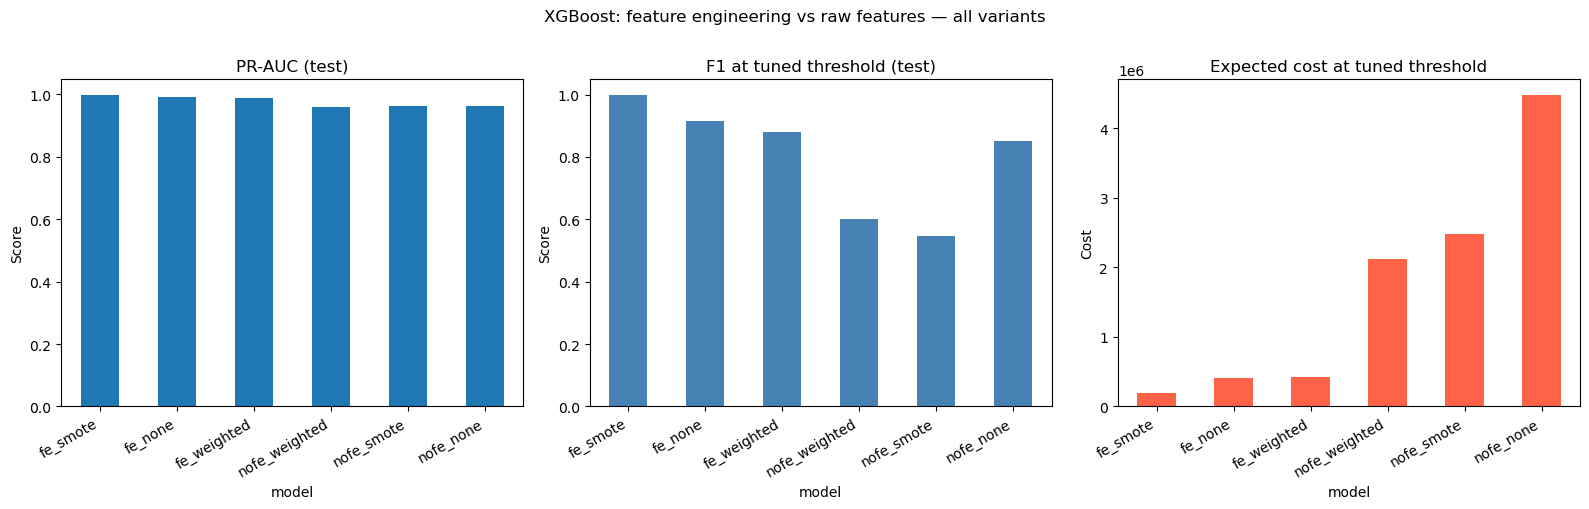

Saved xgboost_comparison.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. PR-AUC
comparison_df.set_index("model")[["test_pr_auc"]].plot(
    kind="bar", ax=axes[0], legend=False
)
axes[0].set_title("PR-AUC (test)")
axes[0].set_ylabel("Score")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

# 2. Tuned F1
comparison_df.set_index("model")[["tuned_f1"]].plot(
    kind="bar", ax=axes[1], legend=False, color="steelblue"
)
axes[1].set_title("F1 at tuned threshold (test)")
axes[1].set_ylabel("Score")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

# 3. Expected cost
comparison_df.set_index("model")[["expected_cost"]].plot(
    kind="bar", ax=axes[2], legend=False, color="tomato"
)
axes[2].set_title("Expected cost at tuned threshold")
axes[2].set_ylabel("Cost")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha="right")

fig.suptitle("XGBoost: feature engineering vs raw features — all variants", y=1.01)
fig.tight_layout()
fig.savefig(results_root / "xgboost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved xgboost_comparison.png")

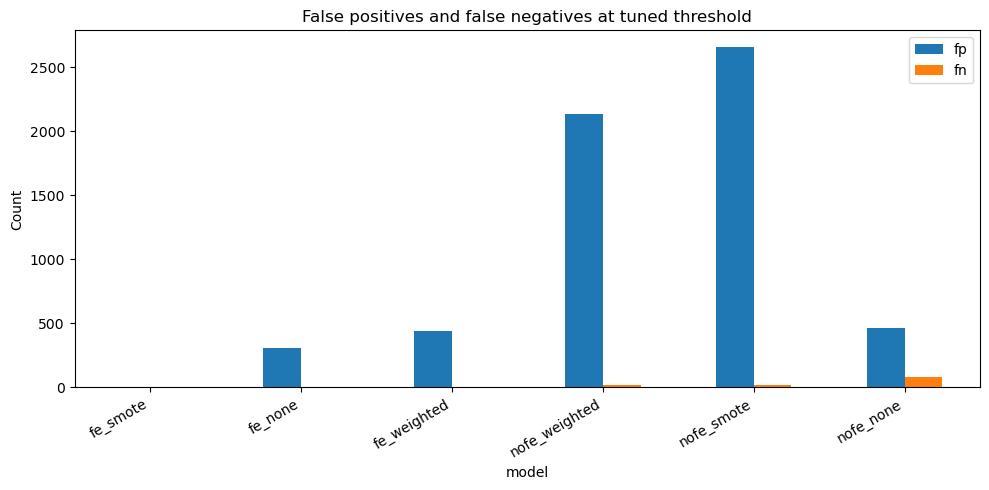

In [30]:
# FP / FN breakdown — shows the precision-recall tradeoff per variant
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.set_index("model")[["fp", "fn"]].plot(kind="bar", ax=ax)
ax.set_title("False positives and false negatives at tuned threshold")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(results_root / "xgboost_fp_fn.png", dpi=150, bbox_inches="tight")
plt.show()

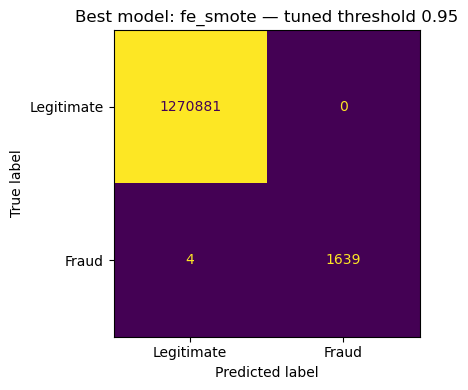

In [31]:
# Confusion matrix for the best model (lowest expected cost)
best = comparison_df.iloc[0]
best_result = next(r for r in all_results if r["label"] == best["model"])

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=best_result["tuned_cm"],
    display_labels=["Legitimate", "Fraud"]
).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title(f"Best model: {best['model']} — tuned threshold {best['best_threshold']:.2f}")
fig.tight_layout()
fig.savefig(results_root / "xgboost_best_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()